dict_keys(['__header__', '__version__', '__globals__', 'Time', 'N', 'Lat', 'Lon', 'Depth', 'Mag'])
no of events 839
completeness 2.6
{'b': np.float64(0.5633903744546764), 'a': np.float64(4.279062569314079), 'Mc': np.float64(2.600000000000001), 'stdDev': np.float64(0.019681144211832587), 'binsize': 0.1}
d:\MEGA\2-Job\RAS\Script-2.0\magnitude-distribution-master


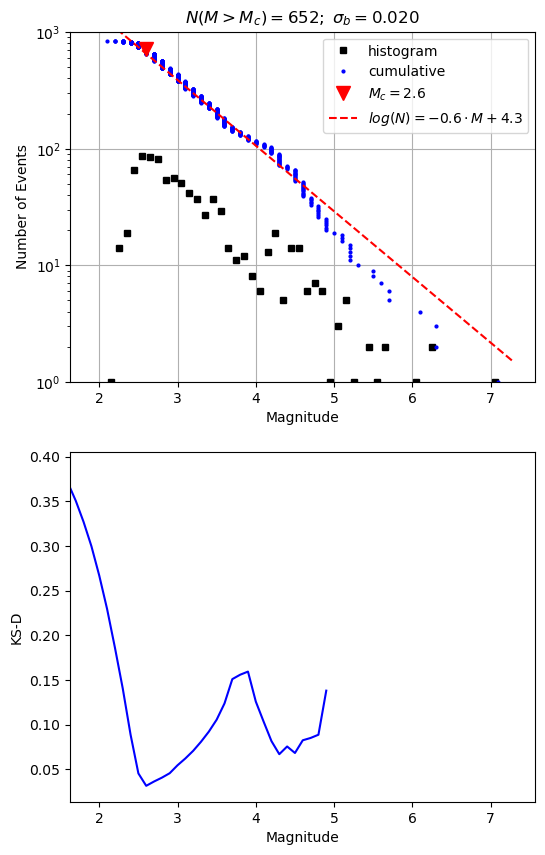

In [1]:
"""
    - fit mag distribution to So Cal data set from
        Hauksson & Shearer 2011:

        2011 - Hauksson, E., W. Yang, P. M. Shearer, Waveform Relocated Earthquake Catalog
         for Southern California (1981 to 2011) (includes 2011-2017 datasets)

        http://scedc.caltech.edu/research-tools/altcatalogs.html
        
                   @author tgoebel U of Memphis, 5/15/2019
"""
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

np.random.seed(123456)
#-------fct. / module def-----------------------------------------------

from src.FMD_GR import FMD
oFMD = FMD()


#============================================================================================================
#                             variables and files
#============================================================================================================
dir_in = 'data'
file_in= 'Chignik_eqs.mat'

binsize = .1
mc_type = np.arange(1.5, 5, binsize)  #'maxCurvature' 'KS' #'MC'#2.5

#=========================================1==================================================================
#                             load data
#============================================================================================================

dEq = scipy.io.loadmat( f"{dir_in}/{file_in}", struct_as_record=False, squeeze_me=True)
print(  dEq.keys())
oFMD.data['mag'] = dEq['Mag']
print( 'no of events', len( dEq['Mag']))

#=========================================2==================================================================
#                             determine Mc and b usign KS-test
#============================================================================================================
oFMD.mag_dist()
a_RanErr = np.random.randn( len( dEq['Mag'])) * binsize*.4
oFMD.data['mag'] += a_RanErr
oFMD.get_Mc( mc_type = mc_type)
oFMD.data['mag'] -= a_RanErr

print( 'completeness', round( oFMD.par['Mc'], 1))
oFMD.fit_GR( binCorrection = 0)
print( oFMD.par)

#=========================================3==================================================================
#                                plot FMD and KS statistic as fct of Mc
#============================================================================================================
#oFMD.plotDistr()
plt.figure(1, figsize = (6,10))
ax1 = plt.subplot(211)
oFMD.plotFit(ax1)
ax2 = plt.subplot( 212)
oFMD.plotKS( ax2)
ax2.set_xlim( ax1.get_xlim())
plt.savefig( file_in.replace( '.mat', '_fmd.png'))
print( os.getcwd())
#plt.show()